# Analysis notebook: `dev_signal_onspill-LH_1a`  

## Define analysis name

In [1]:
ana_label = "dev_signal_onspill-LH_1a"

## Preamble

In [2]:
import sys
sys.path.append("..")
from preamble import *

## Load data

In [3]:
!ls ../../../output/results/dev_signal_onspill-LH_1a

analysis.csv  dev_signal_onspill-LH_1a.log   hists.h5
cut_flow.csv  dev_signal_onspill-LH_1a.yaml  results.pkl


In [4]:
loader = Load(
    in_path = f"../../../output/results/{ana_label}"
)

[Load] ✅ Initialised with out_path=../../../output/results/dev_signal_onspill-LH_1a


In [5]:
results = loader.load_pkl() 
# results_from_persistent = loader.load_all() # Persistent backup 

[Load] ✅ Successfully loaded results from ../../../output/results/dev_signal_onspill-LH_1a/results.pkl


## Analyse results

### Cut flow

In [6]:
display(results["cut_flow"])

,Cut,Group,Events Passing,Absolute [%],Relative [%],Description
0,No cuts,NaN,3688202,100,100,No selection applied
1,has_trk_front,Preselect,3686935,99.966,99.966,Tracks intersect tracker entrance
2,has_trk_mid,Preselect,3686935,99.966,100,Tracks intersect tracker middle
3,one_track_per_event,Preselect,3533680,95.810,95.843,One track / event
4,is_reco_electron,Preselect,3529018,95.684,99.868,Electron track fits
5,is_downstream,Preselect,3528998,95.683,99.999,Downstream tracks (p_z > 0 through tracker)
6,is_truth_electron,Preselect,3528997,95.683,100,Track parents are electrons (truth PID)
7,good_trkqual,Tracker,3337611,90.494,94.577,Track quality > 0.2
8,within_t0,Tracker,2414306,65.460,72.336,t0 at tracker mid (640 < t_0 < 1650 ns)
9,within_t0err,Tracker,2307985,62.578,95.596,Track fit t0 uncertainty (t0err < 0.9 ns)


### Efficiency & rates

In [7]:
display(results["analysis"])

Window,Inclusive,Wide,Extended,Signal
Generated,"4,000,000","4,000,000","4,000,000","4,000,000"
Selected,"2,047,518","2,043,222","1,934,367","1,438,552"
Unvetoed,"2,047,518","2,043,222","1,934,367","1,438,552"
Selection Eff [%],51.188,51.081,48.359,35.964
Selection Eff Err$-$ [%],-0.025,-0.025,-0.025,-0.024
Selection Eff Err$+$ [%],0.025,0.025,0.025,0.024
Veto Eff [%],0,0,0,0
Veto Eff Err$-$ [%],1.11e-14,-2.22e-14,-2.22e-14,-2.22e-14
Veto Eff Err$+$ [%],4.88e-05,4.89e-05,5.17e-05,6.95e-05
Livetime [days],0,0,0,0


### Histograms

In [8]:
# Setup draw for this cutset
on_spill = "offspill" not in ana_label
draw = Draw(cutset_name=ana_label.split('_')[0], on_spill=on_spill)
# Define image directory
img_dir = f"../../../output/images/{ana_label}"
os.makedirs(img_dir, exist_ok=True)

[Load] ✅ Initialised with out_path=test_out
[pyprint] ⭐️ Initialised Print with verbose = False and precision = 1
[Plot] ⭐️ Initialised


[Plot] ✅ 	Wrote ../../../output/images/dev_signal_onspill-LH_1a/h1o_1x3_mom_windows.png


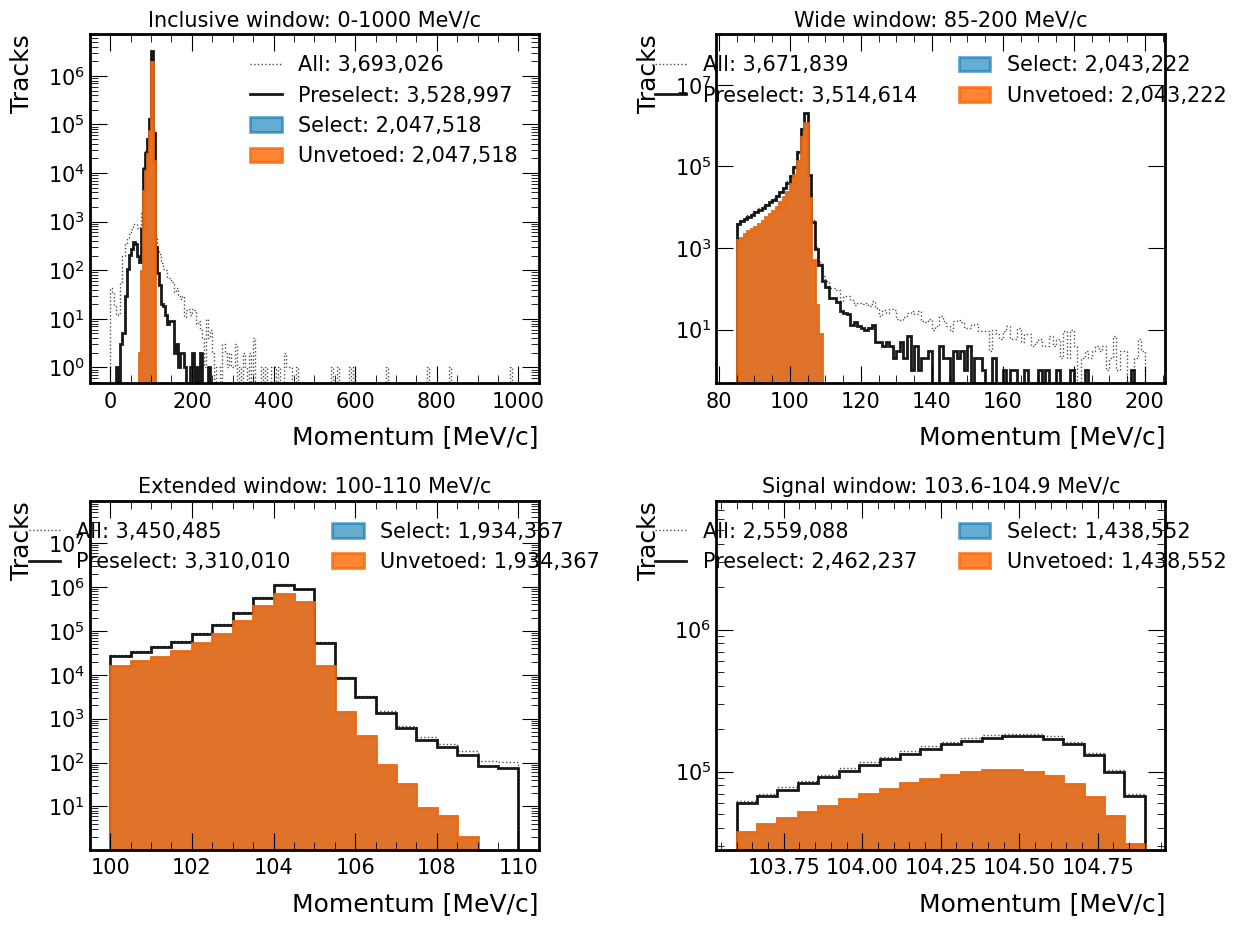

In [9]:
draw.plot_mom_windows(results["hists"], out_path=f"{img_dir}/h1o_1x3_mom_windows.png") 

[Plot] ✅ 	Wrote ../../../output/images/dev_signal_onspill-LH_1a/h1o_3x3_summary.png


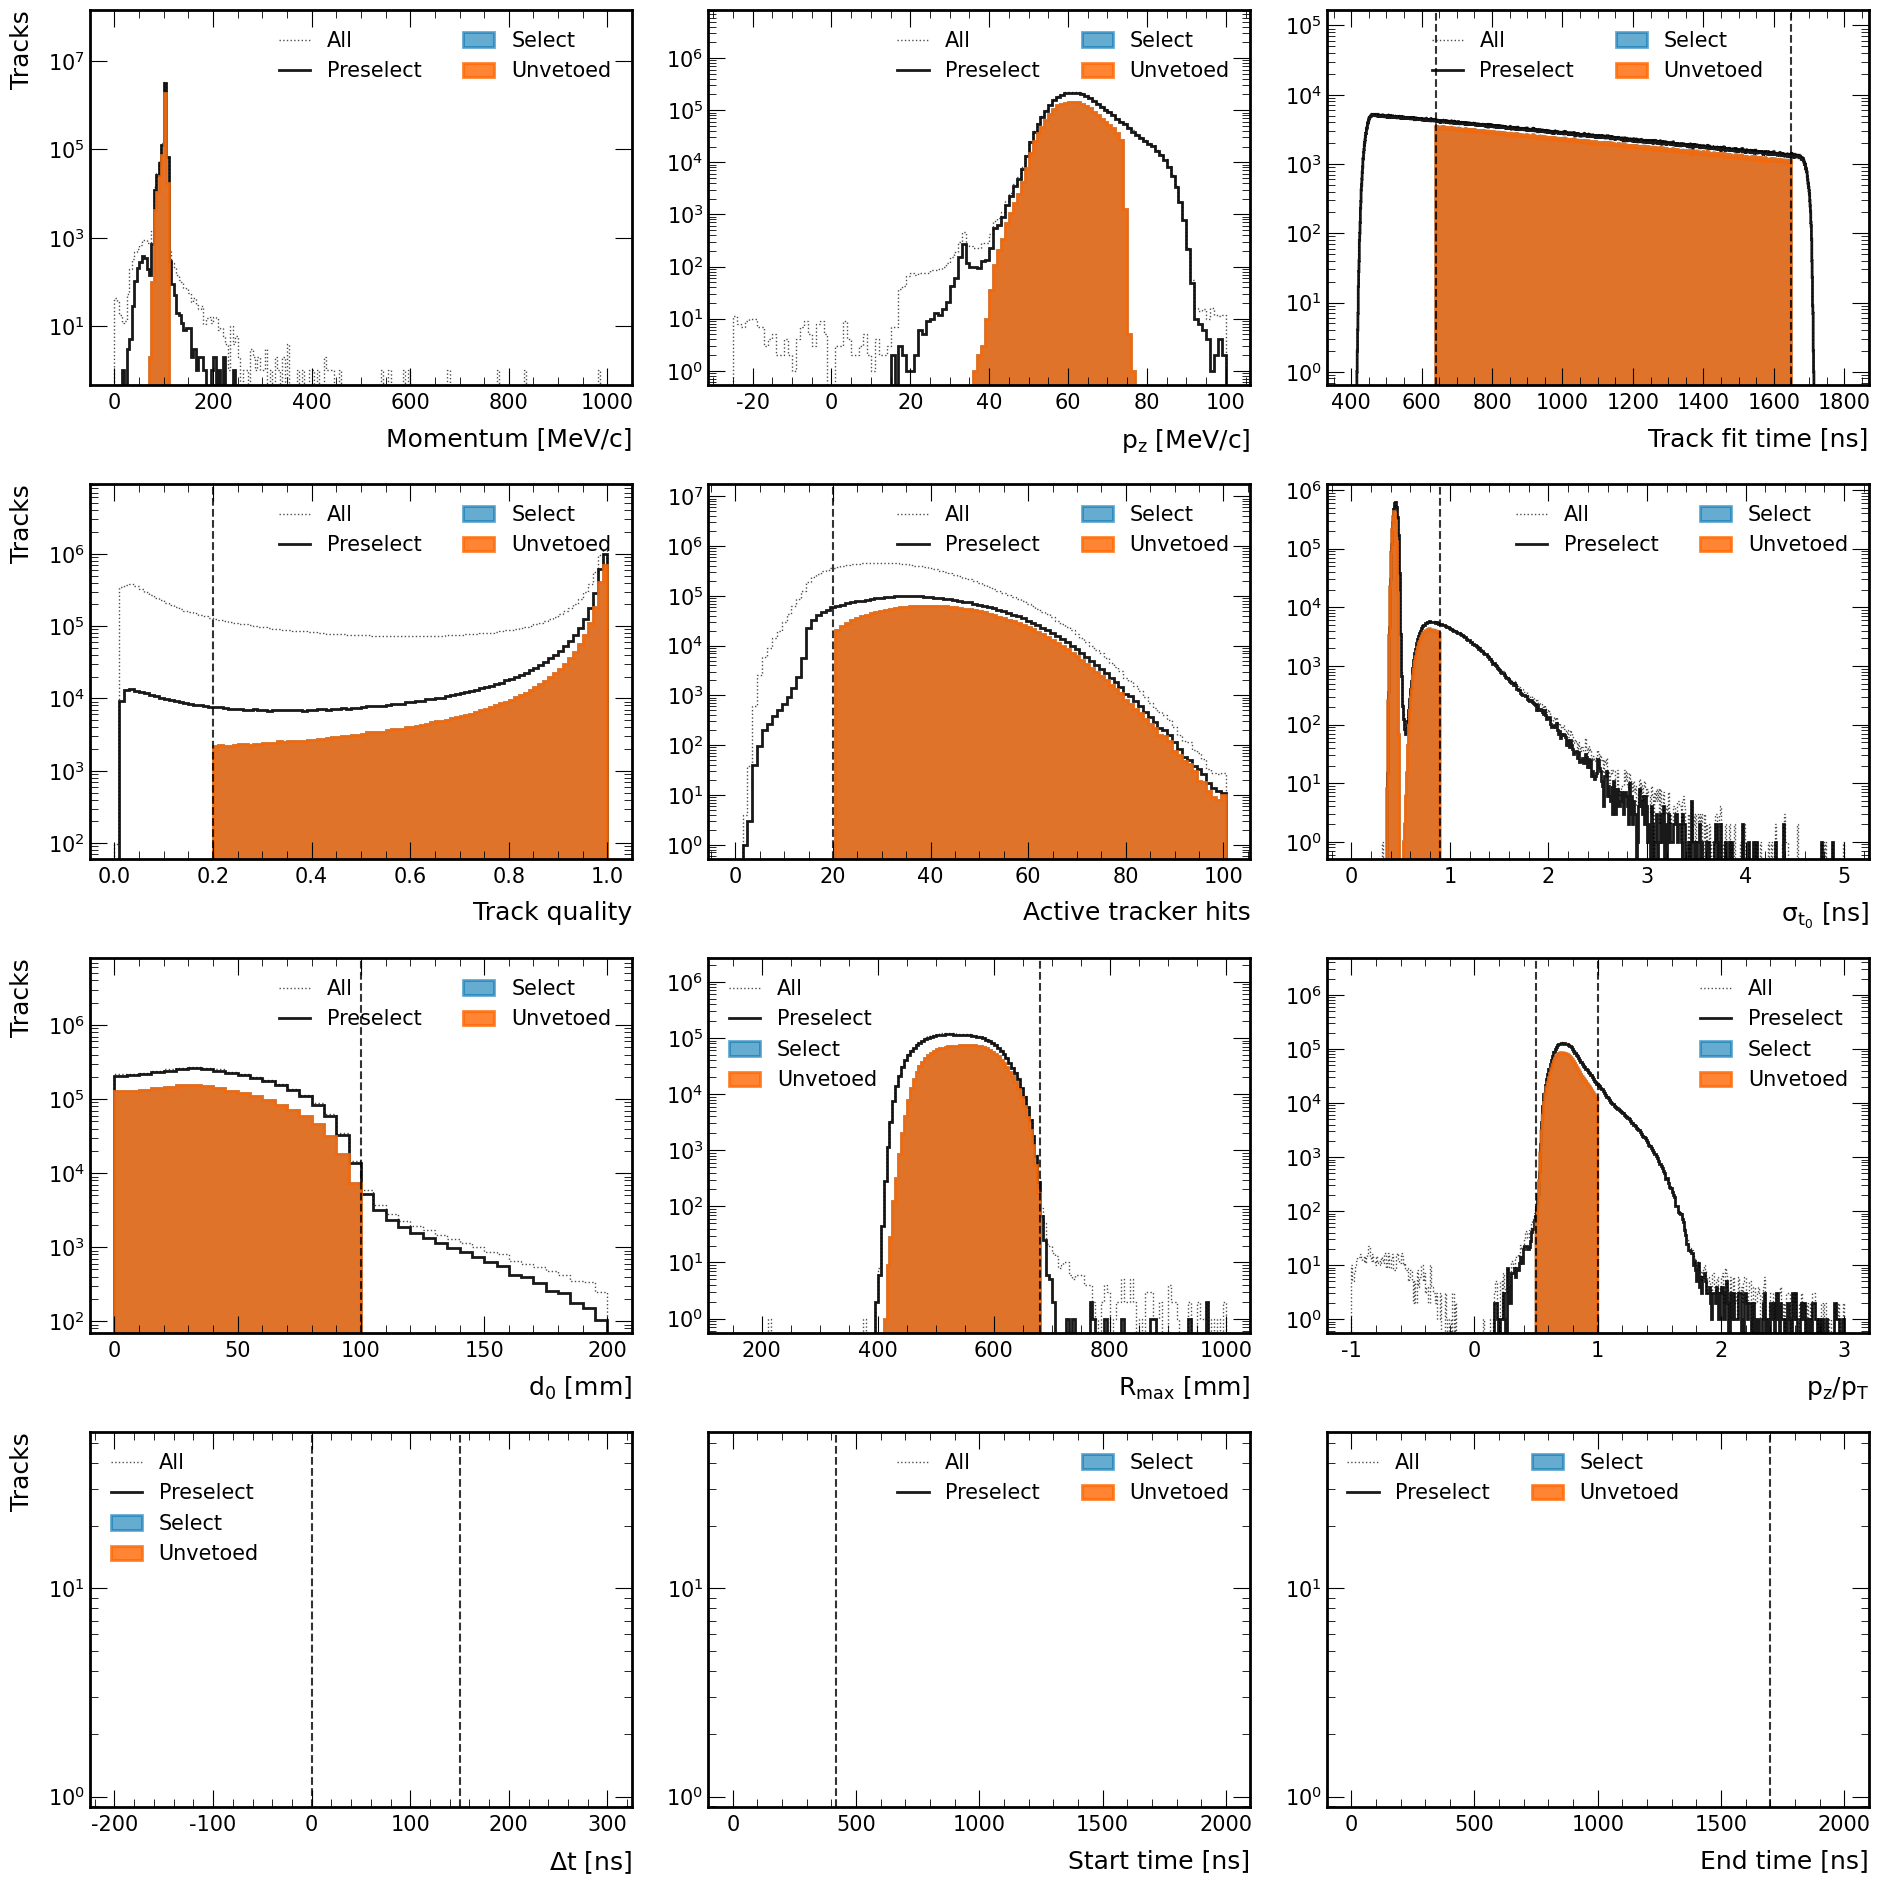

In [10]:
draw.plot_summary(results["hists"], out_path=f"{img_dir}/h1o_3x3_summary.png")

[Plot] ✅ 	Wrote ../../../output/images/dev_signal_onspill-LH_1a/h1o_2x2_mom_summary.png


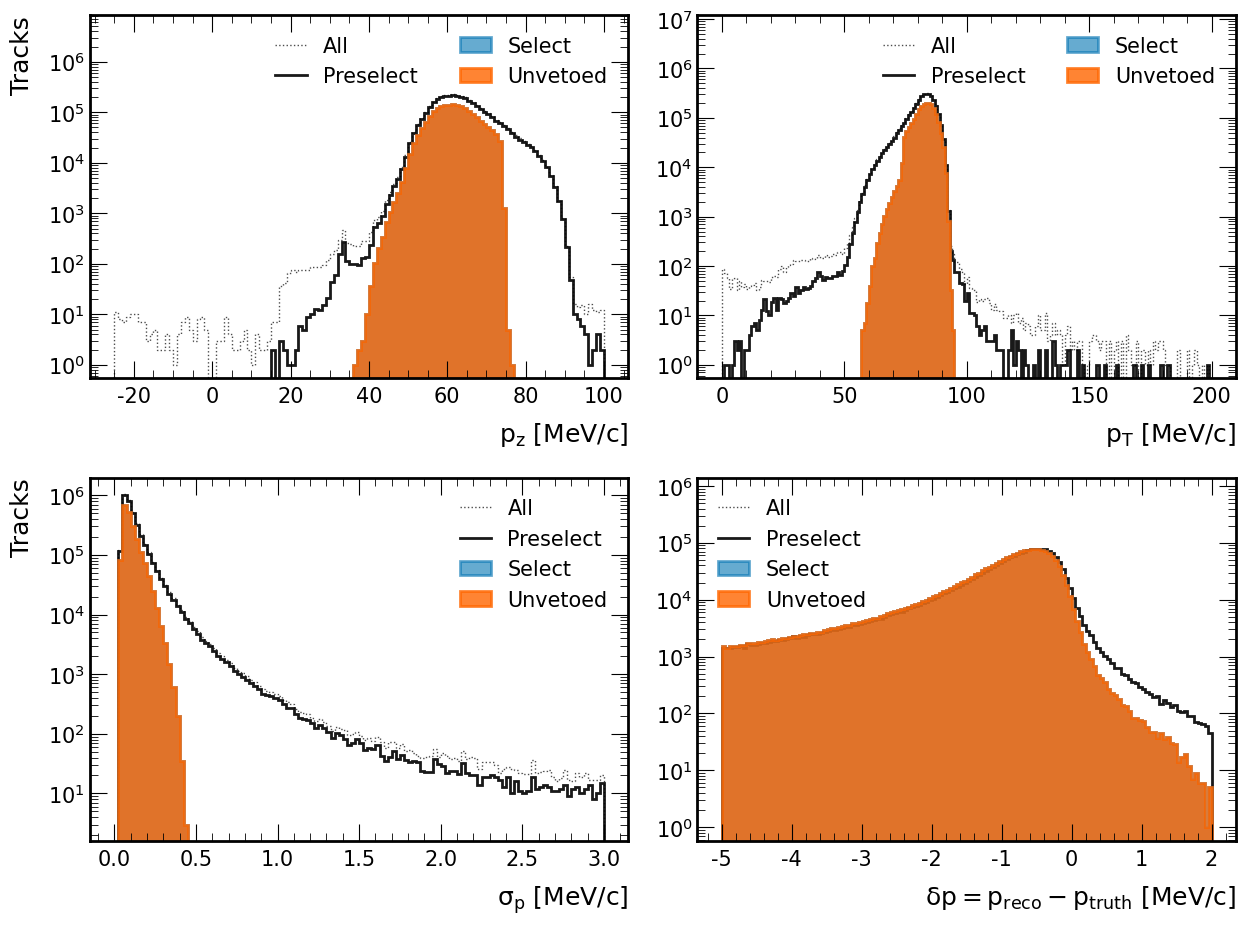

In [11]:
draw.plot_mom_summary(results["hists"], out_path=f"{img_dir}/h1o_2x2_mom_summary.png")

[Plot] ✅ 	Wrote ../../../output/images/dev_signal_onspill-LH_1a/h1o_crv_z.png


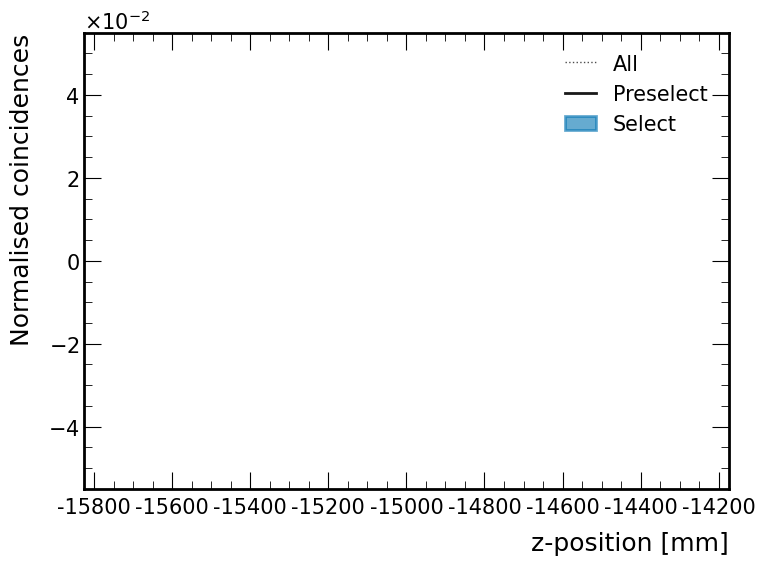

In [12]:
draw.plot_crv_z(results["hists"], out_path=f"{img_dir}/h1o_crv_z.png") 

In [13]:
draw.draw_cosmic_parents_from_array(results["events"], out_path=f"{img_dir}/h1_cosmic_parents.png") 

[Plot] ❌ Error extracting cosmic parents: 'NoneType' object is not subscriptable
[Plot] 🐛 Line 647 in draw_cosmic_parents_from_array of ../../../src/utils/draw.py:
  trkmc = events["trkmc"]


### Background event info

In [ ]:
# print(results["event_info"])

In [ ]:
# if results["events"] is not None:
#     from pyutils.pyprint import Print
#     printer = Print()
#     printer.print_n_events(results["events"], n_events = len(results["events"]))